In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 3** — Drug Discovery Project

Testing combinations of three compounds to minimise adverse reactions. Framed as maximisation of the negated side-effect score.

- **Optimisation Goal:** Maximise (closer to 0 = better)
- **Input:** 3D
- **All-time best:** -0.0199 at [0.307, 0.292, 0.462] (Week 7)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 3
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_outputs.npy')

# New data for Week 8 (Function 3)
X_w7_new_point = np.array([0.307095, 0.291699, 0.462318], dtype=np.float64)
Y_w7_new_point = np.array([-0.019854368699136152], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w7_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w7_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_outputs.npy', Y_updated)

print("Updated Inputs (X) - Function 3: ", X_unique)
print("Updated Outputs (Y) - Function 3: ", Y_updated)

Updated Inputs (X) - Function 3:  [[4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [3.07095000e-01 2.91699000e-01 4.62318000e-01]
 [3.42299000e-01 3.41527000e-01 4.71230000e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [9.06930000e-01 1.42503000e-01 5.04446000e-01]
 [9.09286000e-01 9.74205000e-01 4.75969000e-01]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [9.90267000e-01 6.15090000e-02 8.00335000e-01]
 [9.96

## Output Analysis

- Last week (w6) I saw -0.159 and this week (w7) -0.0199, which is a new all-time best

- **Real-World Implication:** This is the strongest result in the project history for F3. 
    - An output of -0.0199 means the three-compound combination at [0.307, 0.292, 0.462] produces almost no adverse reactions
        - It is also very close to the theoretical ideal of zero.

- **Model Clues:** The balanced, moderate interior of the 3D compound space consistently outperforms extreme combinations. 
    - The w7 result validates this as all three coordinates sit in the 0.29–0.46 range, a genuinely moderate mix. 
    
    - The task now is fine-grained exploitation: staying very close to [0.307, 0.292, 0.462] and searching for marginal improvements that push the score from -0.02 toward -0.01 or better.

- **Key change for W8:** Tighten xi from 0.005 to 0.001 and tighten the focused grid to std=0.02.

## **Bayesian Optimisation**: Gaussian Process Regressor
- **Model:** Matern (nu=2.5) + WhiteKernel with Yeo-Johnson output transformation.

- **Changes for W8:**
    - Kernel held constant — the w7 breakthrough validates the current model architecture completely.
    - Yeo-Johnson transformation retained.

- **Intended impact:** Give the GP a clean gradient signal around the W7 best to identify whether a marginal improvement exists nearby.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)
print('\nFitted kernel:', model.kernel_)

Original Y:    [-0.11804826 -0.04800758 -0.39892551 -0.09418956 -0.1121222  -0.04694741
 -0.08796286 -0.01985437 -0.01352557 -0.11062091 -0.03483531 -0.11141465
 -0.03637783 -0.11386851 -0.10596504 -0.13146061 -0.04432434 -0.04065073
 -0.05675837 -0.13560967 -0.15896951]
Transformed Y: [-0.66880665  0.71473948 -2.29279283 -0.28813635 -0.58132456  0.74291989
 -0.17533315  1.56308605  1.78582963 -0.55845826  1.0847322  -0.57058402
  1.03909152 -0.60756023 -0.48566497 -0.85144661  0.81380825  0.91594561
  0.49207401 -0.9039335  -1.1681855 ]

Fitted kernel: Matern(length_scale=0.165, nu=2.5) + WhiteKernel(noise_level=1e-05)


/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Acquisition Function: EI (xi=0.001) with Tight Focused Grid

- **Strategy:** EI with xi tightened from 0.005 to **0.001**. 
    - This is the most greedy exploitation setting, it tells the model that even a tiny improvement over -0.0199 is worth pursuing, do not wander.

- **Key change for w8:** Focused grid centred on w7 best [0.307, 0.292, 0.462] with std=0.02 (tighter than the 0.05 used previously). 
    - An 80/20 focused/uniform split.

- **Intended impact:** Push the score from -0.0199 closer to -0.01 or better, targeting the true minimum of adverse reactions.

In [4]:
def expected_improvement(X, model, y_max, xi=0.001):
    mu, sigma = model.predict(X, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    with np.errstate(divide='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0] = 0.0
    return ei.ravel()

# Tight focused grid centred on W7 all-time best
w7_best = np.array([0.307095, 0.291699, 0.462318])

x_focused = np.clip(
    np.random.normal(loc=w7_best, scale=0.02, size=(16000, 3)),
    0.000001, 0.999999
)
x_uniform = np.random.uniform(0.000001, 0.999999, (4000, 3))
x_grid = np.vstack([x_focused, x_uniform])

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.001)
next_query = x_grid[np.argmax(ei_values)]

print(f'W7 best coordinates: {w7_best}')
print(f'Strategic Week 8 Query (Function 3): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}')

W7 best coordinates: [0.307095 0.291699 0.462318]
Strategic Week 8 Query (Function 3): 0.374538-0.449618-0.445819


## **Visualisation** - Optimisation Progress

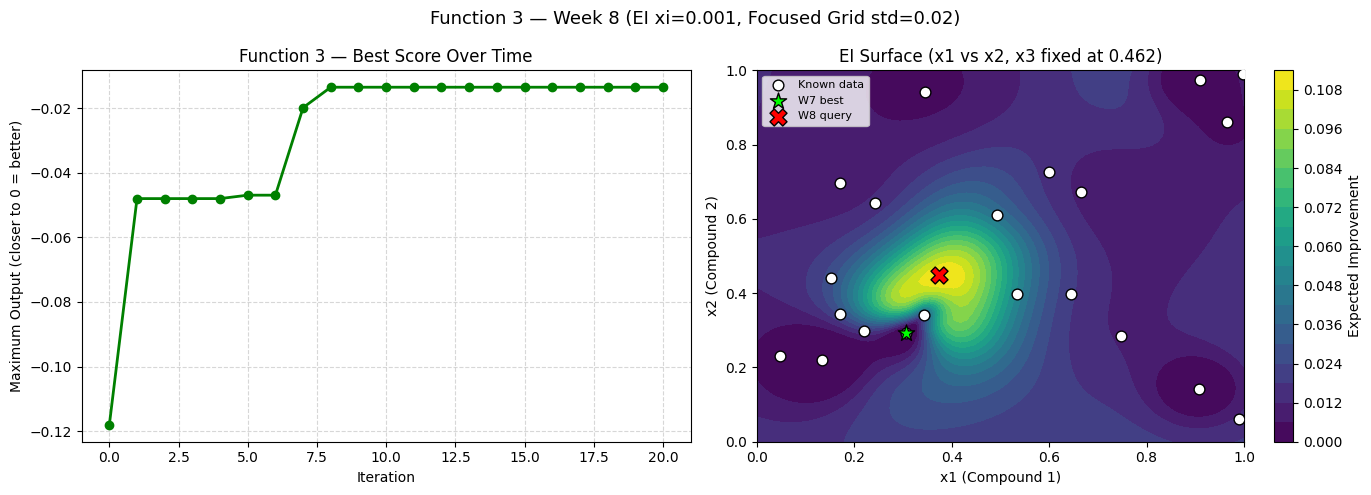

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Progress plot
axes[0].plot(running_max, marker='o', color='green', linewidth=2)
axes[0].set_title('Function 3 — Best Score Over Time')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Maximum Output (closer to 0 = better)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# EI surface for two most relevant dimensions (x1 vs x2, fixing x3 at best)
res = 80
x1_range = np.linspace(0, 1, res)
x2_range = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x1_range, x2_range)
X_slice = np.column_stack([
    X1.ravel(), X2.ravel(),
    np.full(res * res, w7_best[2])
])

ei_slice = expected_improvement(X_slice, model, y_max, xi=0.001).reshape(res, res)
sc = axes[1].contourf(X1, X2, ei_slice, levels=20, cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='Expected Improvement')
axes[1].scatter(X_unique[:, 0], X_unique[:, 1],
                c='white', edgecolors='black', s=60, zorder=5, label='Known data')
axes[1].scatter(w7_best[0], w7_best[1],
                c='lime', edgecolors='black', s=150, marker='*', zorder=6, label='W7 best')
axes[1].scatter(next_query[0], next_query[1],
                c='red', edgecolors='black', s=150, marker='X', zorder=7, label='W8 query')
axes[1].set_title(f'EI Surface (x1 vs x2, x3 fixed at {w7_best[2]:.3f})')
axes[1].set_xlabel('x1 (Compound 1)')
axes[1].set_ylabel('x2 (Compound 2)')
axes[1].legend(fontsize=8)

plt.suptitle('Function 3 — Week 8 (EI xi=0.001, Focused Grid std=0.02)', fontsize=13)
plt.tight_layout()
plt.show()